In [42]:
from pytreenet.contractions.state_operator_contraction import (expectation_value_Lindblad, 
contract_two_ttns, devectorize_pho , split_root_qr, expectation_value, contract_ttno_with_ttn, 
adjust_bra_to_ket, adjust_ttn1_structure_to_ttn2 )

# I appplied a different approach in order to use built-in functions as much as possible. 
# For now, I will neglect bond_expansion and T3NS optimization, to focus on the issue.
# Morover, I would not normalize states, and just consider the normalization factor in the 
expectation_value_Lindblad 
# to just compare with exact results before going further in time. 

# So, first of all, I initiated tdvp with vecrotized_pho with identifier "Site(i,j)" for 
# |ket> part and "Node(i,j)" for <bra| part and corresponding effective Hamiltonian TTNO
# Then after each sweep, I devectorized the vecrotized_pho with
devectorize_pho
# into two TTN;i.e. <bra| and |ket> parts with identifier named "Vertex(i,j)". 
# I only added one attribute "self.connections" for this step.

# Then, I had to deal with the extra virtual bond that connects "Node(0,0)" to "Site(0,0)".
# So, I QR-decomposed the "Vertex(0,0)" with 
split_root_qr
# and kept the Q for "Vertex(0,0)" and pushed the R to the new child named "Vertex(0,0)_R".
# and insert Identity to the corresponding TTNO node in order to calculate the expectation value.

# So, for calculating the expectation value using the finction
expectation_value_Lindblad
# which contracts TTNO locally to |ket> with
contract_ttno_with_ttn 
# and then contracts it with <bra| with built-in function
contract_two_ttns 

# QUESTION: Is contract_ttno_with_ttn good for this step or its more efficient to change
expectation_value
# for calculating <bra|TTNO|ket> ?

# Additionally, I useded to functions :
adjust_bra_to_ket
# and
adjust_ttn1_structure_to_ttn2
# to preserve the initial structure of TTNs due to chnage after 
# applying canical_form and run_one_time_step functions.

<function pytreenet.contractions.state_operator_contraction.adjust_ttn1_structure_to_ttn2(ttn1, ttn2)>

# Initialize state with product of coherent states |$\alpha$>


In [43]:
import pytreenet as ptn
from qutip import coherent
from copy import deepcopy
import numpy as np


def product_state(ttn, bond_dim=2 , physical_dim= 2):
    product_state = deepcopy(ttn)
    A = np.array([0,1])
    alpha = 1
    A = np.array(coherent(physical_dim , alpha).full())
    for node_id in product_state.nodes.keys():
        n = product_state.tensors[node_id].ndim - 1
        tensor = A.reshape((1,) * n + (physical_dim,))
        T = np.pad(tensor, n*((0, bond_dim-1),) + ((0, 0),))
        product_state.tensors[node_id] = T
        product_state.nodes[node_id].link_tensor(T)  
    return product_state

# Initialize vectorized_pho

In [44]:
# local physical dimension
d = 2

shapes = {
    (0, 0): (3, 5, 6, d),
    (0, 1): (3, 7, d),
    (0, 2): (7, 8, d),
    (1, 0): (5, 5, d),
    (1, 1): (9, d),
    (1, 2): (8, d),
    (2, 0): (5, 6, d),
    (2, 1): (6, 9, 3, d),
    (2, 2): (3, d)
}


sites = {
    (i, j): ptn.random_tensor_node(shapes[(i, j)], identifier=f"Site({i},{j})") for i in range(3) for j in range(3)
}

vectorized_pho = ptn.TreeTensorNetworkState()

vectorized_pho.add_root(sites[(0, 0)][0], sites[(0, 0)][1])

connections = [
    ((0, 0), (0, 1), 0, 0),
    ((0, 1), (0, 2), 1, 0),
    ((0, 2), (1, 2), 1, 0),
    ((0, 0), (1, 0), 1, 0),
    ((1, 0), (2, 0), 1, 0),
    ((2, 0), (2, 1), 1, 0),
    ((2, 1), (1, 1), 1, 0),
    ((2, 1), (2, 2), 2, 0)]


for (parent, child, parent_leg, child_leg) in connections:
    parent_id = f"Site({parent[0]},{parent[1]})"
    child_id = f"Site({child[0]},{child[1]})"
    vectorized_pho.add_child_to_parent(sites[child][0], sites[child][1], child_leg, parent_id, parent_leg)

vectorized_pho = product_state(vectorized_pho , bond_dim= 4, physical_dim = d)

nodes = {
    (i, j): (ptn.Node(tensor=vectorized_pho.tensors[f"Site({i},{j})"].conj() , identifier=f"Node({i},{j})"), vectorized_pho.tensors[f"Site({i},{j})"].conj()) for i in range(3) for j in range(3)
}

vectorized_pho.add_child_to_parent(nodes[(0,0)][0], nodes[(0,0)][1], 2, "Site(0,0)", 2)

connections = [
    ((0, 0), (0, 1), 1, 0),
    ((0, 1), (0, 2), 1, 0),
    ((0, 2), (1, 2), 1, 0),
    ((0, 0), (1, 0), 2, 0),
    ((1, 0), (2, 0), 1, 0),
    ((2, 0), (2, 1), 1, 0),
    ((2, 1), (1, 1), 1, 0),
    ((2, 1), (2, 2), 2, 0),
]

for (parent, child, parent_leg, child_leg) in connections:
    parent_id = f"Node({parent[0]},{parent[1]})"
    vectorized_pho.add_child_to_parent(nodes[child][0], nodes[child][1], child_leg, parent_id, parent_leg)

# Effective Hamiltonian

In [45]:
def get_neighbors_Site(x, y, Lx, Ly):
  neighbors = []
  
  # Right neighbor
  if x < Lx - 1:
      neighbors.append(f"Site({x+1},{y})")
  
  # Up neighbor
  if y < Ly - 1:
      neighbors.append(f"Site({x},{y+1})")
  
  return neighbors

def get_neighbors_Node(x, y, Lx, Ly):
  neighbors = []

  # Right neighbor
  if x < Lx - 1:
      neighbors.append(f"Node({x+1},{y})")
  
  # Up neighbor
  if y < Ly - 1:
      neighbors.append(f"Node({x},{y+1})")
  
  return neighbors

In [46]:
def Liouville(t, U, gamma, m, L, Lx, Ly, d):
    creation_op, annihilation_op, number_op = ptn.bosonic_operators(d)
    
    conversion_dict = {
        "b^dagger": creation_op,
        "b": annihilation_op,
        f"I{d}": np.eye(d)
    }
    
    conversion_dict.update({
        "it * b^dagger": t*1j * creation_op,
        "it * b": t*1j * annihilation_op,
        "-iU * n * (n - 1)": -U*1j * number_op @ (number_op - np.eye(d)),
        "im*n": m*1j*number_op
    })
    
    terms = []
    
    # Hopping terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            neighbors = get_neighbors_Site(x, y, Lx, Ly)            
            for neighbor in neighbors:
                terms.append(ptn.TensorProduct({current_site: "it * b^dagger", neighbor: "b"}))
                terms.append(ptn.TensorProduct({current_site: "it * b", neighbor: "b^dagger"}))
                

    
    # On-site interaction terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "-iU * n * (n - 1)"}))

    # Chemical potential terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "im*n"}))        
    
    H1 = ptn.Hamiltonian(terms, conversion_dict)
    
    conversion_dict = {
        "b^dagger.T": creation_op.T,
        "b.T": annihilation_op.T,
        f"I{d}": np.eye(d)
    }
    
    conversion_dict.update({
        "-it * b^dagger.T": -t*1j * creation_op.T,
        "-it * b.T": -t*1j * annihilation_op.T,
        "iU * n * (n - 1).T": (U*1j * number_op @ (number_op - np.eye(d))).T,
        "-im*n.T": -m*1j* number_op.T
    })
    
    terms = []
    
    # Hopping terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Node({x},{y})"
            neighbors = get_neighbors_Node(x, y, Lx, Ly)
            for neighbor in neighbors:
                terms.append(ptn.TensorProduct({current_site: "-it * b^dagger.T", neighbor: "b.T"}))
                terms.append(ptn.TensorProduct({current_site: "-it * b.T", neighbor: "b^dagger.T"}))

    # On-site interaction terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Node({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "iU * n * (n - 1).T"}))    

    # Chemical potential terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Node({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "-im*n.T"}))
            
    H2 = ptn.Hamiltonian(terms, conversion_dict)
    H1.__add__(H2)

        
    conversion_dict = {    
    "L": np.sqrt(gamma) * L,
    "L^dagger.T": np.sqrt(gamma) * L.conj(),
    "-1/2 (L^dagger @ L) " : -1/2 * gamma * L.conj().T @ L,
    "-1/2 (L^dagger @ L).T": -1/2 * gamma * (L.conj().T @ L).T}
    
    terms = []
    for x in range(Lx):
        for y in range(Ly):
            out_site = f"Node({x},{y})"
            in_site = f"Site({x},{y})"
            terms.append(ptn.TensorProduct({in_site: "L" , out_site: "L^dagger.T"}))
            terms.append(ptn.TensorProduct({in_site: "-1/2 (L^dagger @ L) "}))
            terms.append(ptn.TensorProduct({out_site: "-1/2 (L^dagger @ L).T"}))

    H3 = ptn.Hamiltonian(terms, conversion_dict)
    H1.__add__(H3)
    return H1

# Total Occupation 

In [47]:
def Number_op_total(Lx, Ly, dim=2):
    creation_op, annihilation_op, number_op = ptn.bosonic_operators(dim)
    conversion_dict = {"n": number_op , f"I{dim}": np.eye(dim)}
    for dim in range(2, 200):
        conversion_dict[f"I{dim}"] = np.eye(dim)

    terms = []
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Vertex({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "n"}))

    return ptn.Hamiltonian(terms, conversion_dict) 

# Define SecondOrderOneSiteTDVP
gamma = 0

In [48]:
ket , bra = devectorize_pho(vectorized_pho , connections)

t = 0.4
U = 0.8
m = 0.4
creation_op, annihilation_op, number_op = ptn.bosonic_operators(d)
L = annihilation_op 
gamma = 0

# TTNO : Number operator
N = Number_op_total(3, 3, d)
N = N.pad_with_identities(ket, symbolic= True)
N = ptn.TTNO.from_hamiltonian(N, ket)

# TTNO : Liouville operator 
H1 = Liouville(t, U, gamma, m ,L, 3, 3, d)
H1 = H1.pad_with_identities(vectorized_pho , symbolic= True)
L_fancy = ptn.TTNO.from_hamiltonian(H1, vectorized_pho)

connections = [ ((0, 0), (0, 1), 1, 0),
                ((0, 1), (0, 2), 1, 0),
                ((0, 2), (1, 2), 1, 0),
                ((0, 0), (1, 0), 2, 0),
                ((1, 0), (2, 0), 1, 0),
                ((2, 0), (2, 1), 1, 0),
                ((2, 1), (1, 1), 1, 0),
                ((2, 1), (2, 2), 2, 0)]

tdvp_Lindblad = ptn.SecondOrderOneSiteTDVP(initial_state = vectorized_pho,
                                            hamiltonian = L_fancy,
                                            time_step_size = 0.01,
                                            final_time = 4,
                                            operators = N,
                                            connections = connections)

In [49]:
tdvp_Lindblad.run_Lindblad(evaluation_time=2)
times = tdvp_Lindblad.times

  1%|          | 3/401 [00:00<00:23, 16.73it/s]

(6.372660764462141+0j)
(6.372661137084757-1.6291145345388004e-08j)


  2%|▏         | 7/401 [00:00<00:31, 12.55it/s]

(6.372661135040643-1.921222264205034e-08j)
(6.372661135519733-2.488461480779634e-08j)


  3%|▎         | 11/401 [00:00<00:30, 12.80it/s]

...

(6.372662038250646-4.1695516518955604e-05j)
(6.372662040162111-4.176524210032041e-05j)


 99%|█████████▉| 397/401 [00:35<00:00, 12.32it/s]

(6.372662040432311-4.178339828240626e-05j)


100%|██████████| 401/401 [00:36<00:00, 11.10it/s]

(6.372662039078916-4.1744904239165036e-05j)
(6.37266203615747-4.164503816197632e-05j)


# constant results for gamma = 0

c:\Users\edpou\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\edpou\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


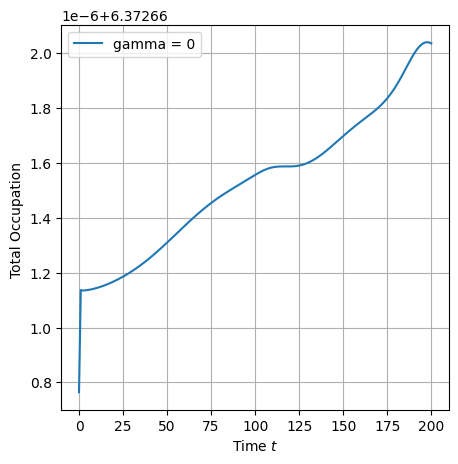

In [50]:
import matplotlib.pyplot as plt

fig1, axs1 = plt.subplots(1, 1, sharex=True, figsize=(5, 5))

axs1.plot( tdvp_Lindblad.operator_results()[0] , label="gamma = 0")

axs1.set_xlabel("Time $t$")
axs1.set_ylabel("Total Occupation ")
axs1.grid(True)
axs1.legend()

# Exact results 
gamma = 1

In [51]:
from qutip import *
import numpy as np

# Define parameters
t = 0.4  # Hopping strength
U = 0.8  # On-site interaction strength
m = 0.4  # Chemical potential
gamma_relax = 1  # Relaxation rate

# Reduced lattice dimensions
Nx = 3  # Number of sites along x-direction
Ny = 3  # Number of sites along y-direction
N = Nx * Ny  # Total number of sites

# Reduced maximum number of bosons per site
nmax = 1

# Precompute the operators for each site
a_list = []
adag_list = []
n_list = []
si = qeye(nmax + 1)  # Identity operator for a single site
for n in range(N):
    op_list = [si] * N
    op_list[n] = destroy(nmax + 1)
    a_op = tensor(op_list)
    a_list.append(a_op)
    adag_list.append(a_op.dag())
    n_list.append(a_op.dag() * a_op)


# Function to map 2D lattice coordinates (i, j) to a site index
def site(i, j):
    return i + j * Nx

# Initialize the Hamiltonian
H = 0

# Build the Hamiltonian by summing over sites
for i in range(Nx):
    for j in range(Ny):
        n = site(i, j)
        H += 0.5 * U * n_list[n] * (n_list[n] - 1) - m * n_list[n]
        if i < Nx - 1:
            n_right = site(i + 1, j)
            H += -t * (adag_list[n] * a_list[n_right] + adag_list[n_right] * a_list[n])
        if j < Ny - 1:
            n_up = site(i, j + 1)
            H += -t * (adag_list[n] * a_list[n_up] + adag_list[n_up] * a_list[n])

# Initial state: product state of maximum occupation

#psi0 = tensor([basis(nmax + 1, nmax) for _ in range(N)]).unit()
# psi0 = tensor([(basis(nmax + 1, 0) + basis(nmax + 1, 1)).unit() for _ in range(N)])
alpha = 1
psi0 = tensor([coherent(nmax + 1, alpha) for _ in range(N)])
# Reduced simulation time and increased time step
total_time = 4  # Total time in seconds
time_step = 0.02  # Time step in seconds
tlist = np.arange(0, total_time + time_step, time_step)

# Define collapse operators (for the Lindblad equation)
custom_matrix = Qobj([[0, 1], [0, 0]])
jump_operator = []
si = qeye(nmax + 1) 
for n in range(N):
  op_list = [si] * N  # Create a list of identity operators
  op_list[n] = custom_matrix  # Replace the n-th site with the custom matrix
  custom_op = tensor(op_list)  # Create the tensor product
  jump_operator.append(custom_op)

c_ops = [np.sqrt(gamma_relax) * a for a in a_list]


# Observables to calculate - total particle number
N_total = sum(n_list)

# Solve the Schrödinger equation (more efficient for this case)
result = mesolve(H, psi0, tlist, c_ops, [N_total])

# Extract expectation values
total_number = result.expect[0]

# Print results
print("Time evolution of total particle number:")
for t, n in zip(tlist, total_number):
    print(f"Time: {t:.2f}, Total number: {n:.4f}")

Time evolution of total particle number:
Time: 0.00, Total number: 6.3727
Time: 0.02, Total number: 6.2465
Time: 0.04, Total number: 6.1228
Time: 0.06, Total number: 6.0015
Time: 0.08, Total number: 5.8827
Time: 0.10, Total number: 5.7662
Time: 0.12, Total number: 5.6520
Time: 0.14, Total number: 5.5401
Time: 0.16, Total number: 5.4304
Time: 0.18, Total number: 5.3229
Time: 0.20, Total number: 5.2175
Time: 0.22, Total number: 5.1142
Time: 0.24, Total number: 5.0129
Time: 0.26, Total number: 4.9137
Time: 0.28, Total number: 4.8164
Time: 0.30, Total number: 4.7210
Time: 0.32, Total number: 4.6275
Time: 0.34, Total number: 4.5359
Time: 0.36, Total number: 4.4461
Time: 0.38, Total number: 4.3580
Time: 0.40, Total number: 4.2717
Time: 0.42, Total number: 4.1871
Time: 0.44, Total number: 4.1042
Time: 0.46, Total number: 4.0230
Time: 0.48, Total number: 3.9433
Time: 0.50, Total number: 3.8652
Time: 0.52, Total number: 3.7887
Time: 0.54, Total number: 3.7137
Time: 0.56, Total number: 3.6401
Ti

# Define SecondOrderOneSiteTDVP
gamma = 1

In [52]:
ket , bra = devectorize_pho(vectorized_pho , connections)

t = 0.4
U = 0.8
m = 0.4
creation_op, annihilation_op, number_op = ptn.bosonic_operators(d)
L = annihilation_op 
gamma = 1

# TTNO : Number operator
N = Number_op_total(3, 3, d)
N = N.pad_with_identities(ket, symbolic= True)
N = ptn.TTNO.from_hamiltonian(N, ket)

# TTNO : Liouville operator 
H1 = Liouville(t, U, gamma, m ,L, 3, 3, d)
H1 = H1.pad_with_identities(vectorized_pho , symbolic= True)
L_fancy = ptn.TTNO.from_hamiltonian(H1, vectorized_pho)

connections = [ ((0, 0), (0, 1), 1, 0),
                ((0, 1), (0, 2), 1, 0),
                ((0, 2), (1, 2), 1, 0),
                ((0, 0), (1, 0), 2, 0),
                ((1, 0), (2, 0), 1, 0),
                ((2, 0), (2, 1), 1, 0),
                ((2, 1), (1, 1), 1, 0),
                ((2, 1), (2, 2), 2, 0)]

tdvp_Lindblad = ptn.SecondOrderOneSiteTDVP(initial_state = vectorized_pho,
                                            hamiltonian = L_fancy,
                                            time_step_size = 0.01,
                                            final_time = 4,
                                            operators = N,
                                            connections = connections)

In [53]:
tdvp_Lindblad.run_Lindblad(evaluation_time=2)
times = tdvp_Lindblad.times

  0%|          | 2/401 [00:00<00:25, 15.72it/s]

(6.372660764462141+0j)


  1%|          | 4/401 [00:00<00:34, 11.47it/s]

(6.473007947827537+3.021190230484492e-05j)


  1%|▏         | 6/401 [00:00<00:37, 10.47it/s]

...

(7.7548351555359964+0.007624098770187139j)


 99%|█████████▉| 397/401 [00:39<00:00,  8.57it/s]

(7.758414614775467+0.007803840626080325j)
(7.762031883786488+0.00798720144746517j)


100%|██████████| 401/401 [00:39<00:00, 10.10it/s]

(7.765690323100105+0.008174149630063684j)
(7.769393106968997+0.00836464283969937j)


# Compare results 

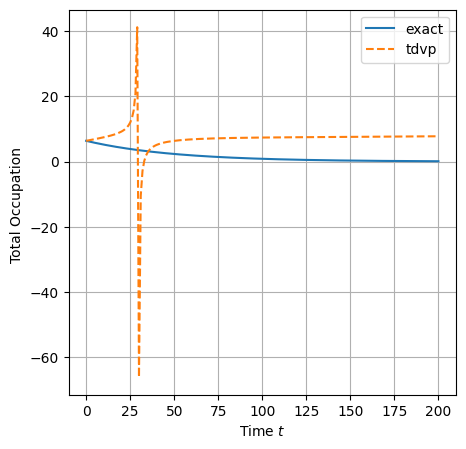

In [54]:
import matplotlib.pyplot as plt

fig1, axs1 = plt.subplots(1, 1, sharex=True, figsize=(5, 5))


axs1.plot(total_number, label="exact" )
axs1.plot( tdvp_Lindblad.operator_results()[0] , label="tdvp", linestyle='--')




# axs1.plot(results_N_ttn, label="N_ttn")
# axs1.plot(results_N_t3n, label="N_t3n")

axs1.set_xlabel("Time $t$")
axs1.set_ylabel("Total Occupation ")
axs1.grid(True)
axs1.legend()